In [146]:
import requests

import matplotlib.pyplot as plt
import seaborn as sns

import umap, numpy as np, pandas as pd

from nltk import FreqDist

import pandas as pd

from sklearn.decomposition import TruncatedSVD
from scipy import sparse
import numpy as np

from collections import Counter
from scipy.sparse import csr_matrix

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import json

from scipy.stats import ttest_ind_from_stats

import os

import gspread
from gspread_dataframe import get_as_dataframe, set_with_dataframe
from google.oauth2 import service_account # based on google-auth library

In [59]:
file_data = json.load(open(os.path.expanduser("../../../ServiceAccountsKey.json")))
# (2) transform the content into crendentials object
credentials = service_account.Credentials.from_service_account_info(file_data)
# (3) specify your usage of the credentials
scoped_credentials = credentials.with_scopes(
    ['https://spreadsheets.google.com/feeds', 'https://www.googleapis.com/auth/drive'])
# (4) use the constrained credentials for authentication of gspread package
gc = gspread.Client(auth=scoped_credentials)

labyrinth_data_gs = gc.open_by_url(
    "https://docs.google.com/spreadsheets/d/1jHk-O5oE47LBAuXLKSfctt1ZwAep7QrYZ5vL-M30vAM/edit?usp=sharing")

In [11]:
labyrinthus_df = pd.read_parquet("../data/large_files/labyrinthus_embeddings.parquet")

In [12]:
# results_df = pd.read_parquet("../data/labyrinthus_classification_results.parquet")
results_df = pd.read_csv("../data/labyrinthus_classification_results.csv")
len(results_df)

186

In [13]:
results_df["emb_type"].unique()

array([nan, 'contextual', 'attention_raw', 'attention_svd',
       'concatenated_raw_attn', 'concatenated',
       'concatenated_raw+baseline'], dtype=object)

In [145]:
results_df["best_model_f1_std"] = results_df.apply(lambda row: row[row["best_model"] + "_f1_std"], axis=1)

In [14]:
results_df.sort_values("best_model_f1_performance", ascending=False).head(50)

,variable_name,model,context,lr_f1_avg,lr_f1_std,lr_f1_max,rf_f1_avg,rf_f1_std,rf_f1_max,hgbc_f1_avg,hgbc_f1_std,hgbc_f1_max,mlp_f1_avg,mlp_f1_std,mlp_f1_max,emb_type,layer,best_model,best_model_f1_performance
165,embed_conc_l7_xlmr&att_conc_l7_xlmr_svd400_emb...,xlmr,concordance,0.671349,0.008412,0.681950,0.469499,0.014061,0.493321,0.600938,0.015908,0.628911,0.678365,0.009921,0.689177,concatenated_raw+baseline,7.0,mlp,0.678365
139,embed_conc_l7_xlmr&att_conc_l7_xlmr_raw_embed&...,xlmr,concordance,0.671358,0.008247,0.681336,0.462370,0.016573,0.492447,0.575715,0.020637,0.600929,0.672104,0.014125,0.689819,concatenated_raw+baseline,7.0,mlp,0.672104
169,embed_conc_l11_xlmr&att_conc_l11_xlmr_svd400_e...,xlmr,concordance,0.666955,0.008807,0.679906,0.450242,0.018330,0.476624,0.613924,0.020463,0.645010,0.669994,0.015768,0.692435,concatenated_raw+baseline,11.0,mlp,0.669994
143,embed_conc_l11_xlmr&att_conc_l11_xlmr_raw_embe...,xlmr,concordance,0.666862,0.009066,0.680514,0.450272,0.016115,0.480057,0.579238,0.014976,0.604486,0.669484,0.018135,0.691985,concatenated_raw+baseline,11.0,mlp,0.669484
168,embed_conc_l10_xlmr&att_conc_l10_xlmr_svd400_e...,xlmr,concordance,0.656956,0.011818,0.671523,0.461649,0.018249,0.492338,0.607008,0.010834,0.629441,0.666619,0.013878,0.686755,concatenated_raw+baseline,10.0,mlp,0.666619
142,embed_conc_l10_xlmr&att_conc_l10_xlmr_raw_embe...,xlmr,concordance,0.656930,0.011929,0.670929,0.453633,0.020726,0.494807,0.542859,0.013853,0.564606,0.666569,0.013835,0.690739,concatenated_raw+baseline,10.0,mlp,0.666569
166,embed_conc_l8_xlmr&att_conc_l8_xlmr_svd400_emb...,xlmr,concordance,0.657032,0.009879,0.669563,0.460837,0.010230,0.479503,0.607516,0.014855,0.646171,0.664124,0.011526,0.680657,concatenated_raw+baseline,8.0,mlp,0.664124
167,embed_conc_l9_xlmr&att_conc_l9_xlmr_svd400_emb...,xlmr,concordance,0.659013,0.010253,0.680318,0.464123,0.013921,0.480780,0.611479,0.014651,0.639868,0.663492,0.007494,0.673908,concatenated_raw+baseline,9.0,mlp,0.663492
140,embed_conc_l8_xlmr&att_conc_l8_xlmr_raw_embed&...,xlmr,concordance,0.657335,0.009655,0.669563,0.454135,0.017047,0.478448,0.562266,0.012008,0.579554,0.663181,0.006258,0.672350,concatenated_raw+baseline,8.0,mlp,0.663181
179,embed_conc_l11_labert&att_conc_l11_labert_svd4...,labert,concordance,0.612981,0.012002,0.631403,0.386769,0.016341,0.417825,0.566262,0.016955,0.595272,0.662855,0.012228,0.675101,concatenated_raw+baseline,11.0,mlp,0.662855


In [15]:
results_df[results_df["context"]=="concordance"].sort_values("best_model_f1_performance", ascending=False).head(50)


,variable_name,model,context,lr_f1_avg,lr_f1_std,lr_f1_max,rf_f1_avg,rf_f1_std,rf_f1_max,hgbc_f1_avg,hgbc_f1_std,hgbc_f1_max,mlp_f1_avg,mlp_f1_std,mlp_f1_max,emb_type,layer,best_model,best_model_f1_performance
165,embed_conc_l7_xlmr&att_conc_l7_xlmr_svd400_emb...,xlmr,concordance,0.671349,0.008412,0.681950,0.469499,0.014061,0.493321,0.600938,0.015908,0.628911,0.678365,0.009921,0.689177,concatenated_raw+baseline,7.0,mlp,0.678365
139,embed_conc_l7_xlmr&att_conc_l7_xlmr_raw_embed&...,xlmr,concordance,0.671358,0.008247,0.681336,0.462370,0.016573,0.492447,0.575715,0.020637,0.600929,0.672104,0.014125,0.689819,concatenated_raw+baseline,7.0,mlp,0.672104
169,embed_conc_l11_xlmr&att_conc_l11_xlmr_svd400_e...,xlmr,concordance,0.666955,0.008807,0.679906,0.450242,0.018330,0.476624,0.613924,0.020463,0.645010,0.669994,0.015768,0.692435,concatenated_raw+baseline,11.0,mlp,0.669994
143,embed_conc_l11_xlmr&att_conc_l11_xlmr_raw_embe...,xlmr,concordance,0.666862,0.009066,0.680514,0.450272,0.016115,0.480057,0.579238,0.014976,0.604486,0.669484,0.018135,0.691985,concatenated_raw+baseline,11.0,mlp,0.669484
168,embed_conc_l10_xlmr&att_conc_l10_xlmr_svd400_e...,xlmr,concordance,0.656956,0.011818,0.671523,0.461649,0.018249,0.492338,0.607008,0.010834,0.629441,0.666619,0.013878,0.686755,concatenated_raw+baseline,10.0,mlp,0.666619
142,embed_conc_l10_xlmr&att_conc_l10_xlmr_raw_embe...,xlmr,concordance,0.656930,0.011929,0.670929,0.453633,0.020726,0.494807,0.542859,0.013853,0.564606,0.666569,0.013835,0.690739,concatenated_raw+baseline,10.0,mlp,0.666569
166,embed_conc_l8_xlmr&att_conc_l8_xlmr_svd400_emb...,xlmr,concordance,0.657032,0.009879,0.669563,0.460837,0.010230,0.479503,0.607516,0.014855,0.646171,0.664124,0.011526,0.680657,concatenated_raw+baseline,8.0,mlp,0.664124
167,embed_conc_l9_xlmr&att_conc_l9_xlmr_svd400_emb...,xlmr,concordance,0.659013,0.010253,0.680318,0.464123,0.013921,0.480780,0.611479,0.014651,0.639868,0.663492,0.007494,0.673908,concatenated_raw+baseline,9.0,mlp,0.663492
140,embed_conc_l8_xlmr&att_conc_l8_xlmr_raw_embed&...,xlmr,concordance,0.657335,0.009655,0.669563,0.454135,0.017047,0.478448,0.562266,0.012008,0.579554,0.663181,0.006258,0.672350,concatenated_raw+baseline,8.0,mlp,0.663181
179,embed_conc_l11_labert&att_conc_l11_labert_svd4...,labert,concordance,0.612981,0.012002,0.631403,0.386769,0.016341,0.417825,0.566262,0.016955,0.595272,0.662855,0.012228,0.675101,concatenated_raw+baseline,11.0,mlp,0.662855


In [16]:
results_df[results_df["model"]=="labert_wsd"].sort_values("best_model_f1_performance", ascending=False).head(50)


,variable_name,model,context,lr_f1_avg,lr_f1_std,lr_f1_max,rf_f1_avg,rf_f1_std,rf_f1_max,hgbc_f1_avg,hgbc_f1_std,hgbc_f1_max,mlp_f1_avg,mlp_f1_std,mlp_f1_max,emb_type,layer,best_model,best_model_f1_performance
185,embed_conc_l11_labert_wsd&att_conc_l11_labert_...,labert_wsd,concordance,0.618757,0.010207,0.633836,0.402122,0.018426,0.430994,0.572202,0.011256,0.586172,0.662454,0.011277,0.677786,concatenated_raw+baseline,11.0,mlp,0.662454
159,embed_conc_l11_labert_wsd&att_conc_l11_labert_...,labert_wsd,concordance,0.618934,0.010166,0.633836,0.417164,0.025687,0.466736,0.539349,0.016354,0.566613,0.660729,0.009097,0.679537,concatenated_raw+baseline,11.0,mlp,0.660729
156,embed_l11_labert_wsd&att_l11_labert_wsd_raw_em...,labert_wsd,sentence,0.620552,0.014105,0.642984,0.457631,0.019046,0.482663,0.553655,0.019046,0.576864,0.646326,0.008684,0.659529,concatenated_raw+baseline,11.0,mlp,0.646326
182,embed_l11_labert_wsd&att_l11_labert_wsd_svd400...,labert_wsd,sentence,0.619976,0.015130,0.642659,0.463536,0.021443,0.494599,0.566236,0.011981,0.591381,0.643605,0.009678,0.656659,concatenated_raw+baseline,11.0,mlp,0.643605
158,embed_conc_l10_labert_wsd&att_conc_l10_labert_...,labert_wsd,concordance,0.581626,0.009236,0.599065,0.372800,0.019850,0.393643,0.477547,0.013597,0.494172,0.641262,0.008166,0.651622,concatenated_raw+baseline,10.0,mlp,0.641262
157,embed_conc_l9_labert_wsd&att_conc_l9_labert_ws...,labert_wsd,concordance,0.577151,0.013872,0.598491,0.352661,0.024736,0.386883,0.458688,0.016080,0.482464,0.636024,0.009590,0.646332,concatenated_raw+baseline,9.0,mlp,0.636024
183,embed_conc_l9_labert_wsd&att_conc_l9_labert_ws...,labert_wsd,concordance,0.577111,0.013601,0.598491,0.366951,0.020299,0.392930,0.521331,0.024468,0.573378,0.635052,0.015416,0.652720,concatenated_raw+baseline,9.0,mlp,0.635052
184,embed_conc_l10_labert_wsd&att_conc_l10_labert_...,labert_wsd,concordance,0.581399,0.008835,0.597348,0.370954,0.015324,0.393660,0.521748,0.010250,0.538915,0.632670,0.009406,0.651478,concatenated_raw+baseline,10.0,mlp,0.632670
181,embed_l10_labert_wsd&att_l10_labert_wsd_svd400...,labert_wsd,sentence,0.599500,0.018825,0.626384,0.444630,0.017363,0.470247,0.548169,0.013323,0.572814,0.631743,0.010925,0.650508,concatenated_raw+baseline,10.0,mlp,0.631743
155,embed_l10_labert_wsd&att_l10_labert_wsd_raw_em...,labert_wsd,sentence,0.598991,0.019420,0.628596,0.439111,0.019706,0.466561,0.525969,0.015667,0.547033,0.629191,0.013575,0.657258,concatenated_raw+baseline,10.0,mlp,0.629191


In [50]:
# t-test...

from scipy.stats import ttest_ind_from_stats

# Example data:
mean1, std1, nobs1 = 0.678365, 0.009921, 10
mean2, std2, nobs2 = 0.672104, 0.014125, 10
# Welch’s t-test (default: equal_var=False)
t_stat, p_val = ttest_ind_from_stats(mean1=mean1, std1=std1, nobs1=nobs1,
                                     mean2=mean2, std2=std2, nobs2=nobs2,
                                     equal_var=False)

print(f"t = {t_stat:.3f}, p = {p_val:.4f}")

t = 1.147, p = 0.2681


## Models for close inspection

In [ ]:
# ------------------------------------------------------------------
# common objects
# ------------------------------------------------------------------
y = labyrinthus_df["classification_single_label"].values  # 21 classes incl. “other”
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [107]:
import importlib
import helpers
importlib.reload(helpers)
from helpers import *

In [108]:
y_preds = {}

In [109]:
results_df[results_df["model"]=="baseline"].sort_values("best_model_f1_performance", ascending=False).head(5)

,variable_name,model,context,lr_f1_avg,lr_f1_std,lr_f1_max,rf_f1_avg,rf_f1_std,rf_f1_max,hgbc_f1_avg,hgbc_f1_std,hgbc_f1_max,mlp_f1_avg,mlp_f1_std,mlp_f1_max,emb_type,layer,best_model,best_model_f1_performance
1,cooc_conc_vector,baseline,concordance,0.610300,0.010050,0.622798,0.578055,0.007089,0.584911,0.342613,0.012533,0.357608,0.617580,0.011744,0.634357,NaN,NaN,mlp,0.617580
3,svd400_conc,baseline,concordance,0.606972,0.012784,0.631276,0.452227,0.017605,0.487993,0.555581,0.012203,0.574610,0.568914,0.012030,0.585495,NaN,NaN,lr,0.606972
0,cooc_vector,baseline,sentence,0.596139,0.010777,0.615395,0.582567,0.011020,0.595004,0.452998,0.015910,0.474547,0.601046,0.013481,0.620606,NaN,NaN,mlp,0.601046
2,svd400,baseline,sentence,0.596603,0.011137,0.613829,0.513865,0.021034,0.547947,0.563190,0.014136,0.587494,0.565572,0.013050,0.584094,NaN,NaN,lr,0.596603


In [121]:
# best performing baseline
emb = "cooc_conc_vector"
y_pred, acc, f1 = run_classifier(emb, mlp, y, cv)
title = emb + "_mlp"
y_preds[title] = y_pred
f1

0.6091130110235112

In [110]:
results_df[results_df["emb_type"]=="contextual"].sort_values("best_model_f1_performance", ascending=False).head(5)

,variable_name,model,context,lr_f1_avg,lr_f1_std,lr_f1_max,rf_f1_avg,rf_f1_std,rf_f1_max,hgbc_f1_avg,hgbc_f1_std,hgbc_f1_max,mlp_f1_avg,mlp_f1_std,mlp_f1_max,emb_type,layer,best_model,best_model_f1_performance
9,embed_conc_l7_xlmr,xlmr,concordance,0.602678,0.015273,0.620548,0.457403,0.015342,0.493499,0.566763,0.018473,0.589697,0.603445,0.013812,0.635687,contextual,7.0,mlp,0.603445
8,embed_l11_xlmr,xlmr,sentence,0.598738,0.015836,0.619720,0.477191,0.023497,0.509964,0.548177,0.018037,0.575191,0.602261,0.012341,0.623725,contextual,11.0,mlp,0.602261
6,embed_l9_xlmr,xlmr,sentence,0.590026,0.008578,0.605129,0.463747,0.021535,0.492657,0.535292,0.014657,0.558873,0.596887,0.010888,0.616544,contextual,9.0,mlp,0.596887
4,embed_l7_xlmr,xlmr,sentence,0.589804,0.013232,0.608653,0.468851,0.025205,0.507712,0.547676,0.017850,0.578865,0.596556,0.009879,0.612941,contextual,7.0,mlp,0.596556
10,embed_conc_l8_xlmr,xlmr,concordance,0.593086,0.010145,0.604784,0.445574,0.018321,0.478535,0.553239,0.014845,0.576246,0.596355,0.008064,0.607240,contextual,8.0,mlp,0.596355


In [111]:
# best performing contextual
emb = "embed_l7_xlmr"
y_pred, acc, f1 = run_classifier(emb, mlp, y, cv)
title = emb + "_mlp"
y_preds[title] = y_pred
f1

0.6107303212618831

In [135]:
results_df[(results_df["emb_type"]=="contextual") & (results_df["model"].str.startswith("labert"))].sort_values("best_model_f1_performance", ascending=False).head(5)


,variable_name,model,context,lr_f1_avg,lr_f1_std,lr_f1_max,rf_f1_avg,rf_f1_std,rf_f1_max,hgbc_f1_avg,hgbc_f1_std,hgbc_f1_max,mlp_f1_avg,mlp_f1_std,mlp_f1_max,emb_type,layer,best_model,best_model_f1_performance
29,embed_conc_l11_labert_wsd,labert_wsd,concordance,0.588387,0.013234,0.603376,0.394918,0.018302,0.422608,0.514760,0.013260,0.537784,0.595185,0.010641,0.609160,contextual,11.0,mlp,0.595185
23,embed_conc_l11_labert,labert,concordance,0.583981,0.012095,0.599196,0.390038,0.016890,0.415793,0.514905,0.011527,0.531142,0.586027,0.009750,0.599571,contextual,11.0,mlp,0.586027
26,embed_l11_labert_wsd,labert_wsd,sentence,0.578026,0.012848,0.597396,0.436075,0.019615,0.459730,0.502461,0.020885,0.534094,0.580289,0.013691,0.604382,contextual,11.0,mlp,0.580289
18,embed_l11_labert,labert,sentence,0.571586,0.018774,0.599309,0.427795,0.021294,0.460951,0.503007,0.017505,0.526998,0.573163,0.016149,0.601841,contextual,11.0,mlp,0.573163
20,embed_conc_l8_labert,labert,concordance,0.538688,0.014416,0.554142,0.326286,0.016133,0.355901,0.422045,0.013846,0.449478,0.552444,0.012797,0.574232,contextual,8.0,mlp,0.552444


In [113]:
# best performing contextual
emb = "embed_conc_l11_labert_wsd"
y_pred, acc, f1 = run_classifier(emb, mlp, y, cv)
title = emb + "_mlp"
y_preds[title] = y_pred
f1

0.5932083117052358

In [134]:
# best attention model
results_df[results_df["emb_type"]=="attention_raw"].sort_values("best_model_f1_performance", ascending=False).head(5)

,variable_name,model,context,lr_f1_avg,lr_f1_std,lr_f1_max,rf_f1_avg,rf_f1_std,rf_f1_max,hgbc_f1_avg,hgbc_f1_std,hgbc_f1_max,mlp_f1_avg,mlp_f1_std,mlp_f1_max,emb_type,layer,best_model,best_model_f1_performance
39,att_conc_l11_xlmr_raw_embed,xlmr,concordance,0.075885,0.000000,0.075885,0.539474,0.008719,0.554881,0.330079,0.015467,0.348147,0.579193,0.016269,0.601645,attention_raw,11.0,mlp,0.579193
52,att_l11_labert_wsd_raw_embed,labert_wsd,sentence,0.100027,0.001660,0.102121,0.577889,0.014919,0.601144,0.420520,0.013720,0.438757,0.556827,0.012903,0.579991,attention_raw,11.0,rf,0.577889
34,att_l11_xlmr_raw_embed,xlmr,sentence,0.075885,0.000000,0.075885,0.571468,0.011377,0.583634,0.421967,0.016241,0.445723,0.568858,0.010219,0.584956,attention_raw,11.0,rf,0.571468
40,att_l7_labert_raw_embed,labert,sentence,0.105607,0.001855,0.108212,0.570570,0.011092,0.592081,0.425430,0.015374,0.451695,0.523934,0.013514,0.550113,attention_raw,7.0,rf,0.570570
44,att_l11_labert_raw_embed,labert,sentence,0.104102,0.001690,0.106311,0.569972,0.011906,0.586324,0.407600,0.014280,0.432222,0.533284,0.013963,0.552581,attention_raw,11.0,rf,0.569972


In [115]:
# best performing attention
emb = "att_conc_l11_xlmr_raw_embed"
y_pred, acc, f1 = run_classifier(emb, mlp, y, cv)
title = emb + "_mlp"
y_preds[title] = y_pred
f1

0.5767707195791365

In [116]:
title =  'embed_l11_xlmr&att_l11_xlmr_raw_embed' + "_mlp"
emb1 = "embed_l11_xlmr"
emb2 = "att_l11_xlmr_raw_embed"
y_pred, acc, f1 = run_classifier([emb1, emb2], mlp, y, cv)
y_preds[title] = y_pred
f1

0.6138539522857909

In [117]:
# best performing combo
L = 7
model = "xlmr"
emb1 = f"embed_conc_l{L}_{model}"
emb2 = f"att_conc_l{L}_{model}_raw_embed"
emb3 = "cooc_conc_vector"
title = f"{emb1}&{emb2}&{emb3}" + "_mlp"
emb_cols = [emb1, emb2, emb3]
y_pred, acc, f1 = run_classifier(emb_cols, mlp, y, cv)
y_preds[title] = y_pred
f1

0.6715670866800524

In [118]:
y_preds.keys()

dict_keys(['embed_l7_xlmr_mlp', 'embed_conc_l11_labert_wsd_mlp', 'att_conc_l11_xlmr_raw_embed_mlp', 'embed_l11_xlmr&att_l11_xlmr_raw_embed_mlp', 'embed_conc_l7_xlmr&att_conc_l7_xlmr_raw_embed&cooc_conc_vector_mlp'])

In [123]:
for title, y_pred in y_preds.items():
    labyrinthus_df[title] = y_pred

In [124]:
labyrinthus_df.columns

Index(['author', 'title', 'grela_id', 'sentence_id', 'sentence_text',
       'context_3sents', 'tokens', 'concordance_tokens', 'not_before',
       'not_after', 'date_random', 'lagt_genre', 'lagt_provenience',
       'noscemus_genre', 'noscemus_discipline', 'target_token_id',
       'target_char_start', 'target_char_end', 'concordance_tokens_str',
       'classification_single', 'classification_single_label', 'xlmr_sentence',
       'xlmr_sp_tokens', 'xlmr_aug_tokens', 'xlmr_conc_text',
       'xlmr_conc_sp_tokens', 'xlmr_conc_aug_tokens', 'labert_sentence',
       'labert_sp_tokens', 'labert_aug_tokens', 'labert_conc_text',
       'labert_conc_sp_tokens', 'labert_conc_aug_tokens', 'cooc_vector',
       'cooc_conc_vector', 'svd400', 'svd400_conc', 'cooc_conc_vector_mlp',
       'embed_l11_xlmr&att_l11_xlmr_raw_embed_mlp',
       'embed_conc_l7_xlmr&att_conc_l7_xlmr_raw_embed&cooc_conc_vector_mlp',
       'embed_l7_xlmr_mlp', 'embed_conc_l11_labert_wsd_mlp',
       'att_conc_l11_xlmr_ra

In [125]:
labyrinthus_sample100_bestclass = labyrinthus_df[y_preds.keys()].sample(n=100, random_state=0)
labyrinthus_sample100_bestclass.head(5)

,embed_l7_xlmr_mlp,embed_conc_l11_labert_wsd_mlp,att_conc_l11_xlmr_raw_embed_mlp,embed_l11_xlmr&att_l11_xlmr_raw_embed_mlp,embed_conc_l7_xlmr&att_conc_l7_xlmr_raw_embed&cooc_conc_vector_mlp,cooc_conc_vector_mlp
252,confusion_metaphorics,confusion_metaphorics,confusion_metaphorics,confusion_metaphorics,confusion_metaphorics,confusion_metaphorics
817,confusion_metaphorics,confusion_metaphorics,scientific_complexity_metaphorics,confusion_metaphorics,scientific_complexity_metaphorics,confusion_metaphorics
144,confusion_metaphorics,confusion_metaphorics,confusion_metaphorics,confusion_metaphorics,confusion_metaphorics,confusion_metaphorics
750,confusion_metaphorics,mythological,confusion_metaphorics,confusion_metaphorics,confusion_metaphorics,medical_anatomical
145,scientific_complexity_metaphorics,confusion_metaphorics,scientific_complexity_metaphorics,confusion_metaphorics,scientific_complexity_metaphorics,scientific_complexity_metaphorics


In [126]:
labyrinthus_sample100_annotated = get_as_dataframe(labyrinth_data_gs.worksheet("labyrinthus_sample100_classified"))
labyrinthus_sample100_annotated.head(5)

,author,title,grela_id,sentence_id,sentence_text,context_3sents,classification_single_label,GT by SL,GT by VK,CORRECTED/comments,not_before,not_after,date_random,lagt_genre,lagt_provenience,noscemus_genre,noscemus_discipline,target_token_id,target_char_start,target_char_end
0,Abbo Floriacensisc.945–1004,Epistolae,cc_9744,cc_9744_198,Sub ouina pelle lupi ad monasterii asylum conf...,"U, 11) qui turbare rempublicam maximum lucrum ...",confusion_metaphorics,confusion_metaphorics,confusion_metaphorics,NaN,945.0,1004.0,973.0,NaN,NaN,NaN,NaN,355686228,310,321
1,"Castelli, Bartolomeo",Lexicon medicum Graecolatinum Bartholomaei Cas...,noscemus_888129,noscemus_888129_80,"Sic dubia is Ueterum, perplexaque dogmata seru...",Nam ueluti Alcidem ducentia fila sequutum Fama...,scientific_complexity_metaphorics,mythological,mythological,"Alcides is Herkules, so it should be myth",1598.0,1598.0,1598.0,NaN,NaN,Dictionary/Lexicon,Medicine,139552692,108,119
2,"Masenius, Jacobus",Exercitationes Oratoriae,cc_13980,cc_13980_8385,"an ignorabit, non aliud ab illis bellum esse s...","An non intelligit, iisdem se armis, iisdem art...",scientific_complexity_metaphorics,confusion_metaphorics,scientific_complexity_metaphorics,this was hard... it's definitely metaphorical ...,1606.0,1681.0,1680.0,NaN,NaN,NaN,NaN,208107516,447,458
3,"Stansel, Valentin",Uranophilus caelestis peregrinus sive mentis U...,noscemus_797514,noscemus_797514_11056,"Ex uno labyrintho in alium me trahis, o Uranop...",Urania. | Ex uno labyrintho in alium me trahis...,scientific_complexity_metaphorics,mythological,mythological,NaN,1685.0,1685.0,1685.0,NaN,NaN,Dialogue,"Physics, Astronomy/Astrology/Cosmography, Geog...",138519449,7,17
4,"Masenius, Jacobus",Familiarium argutiarum fontes.,cc_13981,cc_13981_8473,Hoc igitur sophisma quendam inuoluit labyrinthum.,"Ne igitur falsus sis, teneor te in captiuitate...",confusion_metaphorics,confusion_metaphorics,confusion_metaphorics,NaN,1606.0,1681.0,1668.0,NaN,NaN,NaN,NaN,185378378,37,48


In [127]:
labyrinthus_sample_annotated_merged = pd.concat([labyrinthus_sample100_annotated.reset_index(drop=True), labyrinthus_sample100_bestclass.reset_index(drop=True)], axis=1)

In [128]:
f1_macro = f1_score(labyrinthus_sample_annotated_merged['GT by VK'], labyrinthus_sample_annotated_merged['classification_single_label'], average='macro')
f1_macro

0.7338700997983275

In [130]:
for y_pred in y_preds.keys():
    print(y_pred, f1_score(labyrinthus_sample_annotated_merged['GT by VK'], labyrinthus_sample_annotated_merged[y_pred], average='macro'))


embed_l7_xlmr_mlp 0.53695732293116
embed_conc_l11_labert_wsd_mlp 0.5708085124751792
att_conc_l11_xlmr_raw_embed_mlp 0.5082770247978688
embed_l11_xlmr&att_l11_xlmr_raw_embed_mlp 0.4941358076951297
embed_conc_l7_xlmr&att_conc_l7_xlmr_raw_embed&cooc_conc_vector_mlp 0.6111530082118318
cooc_conc_vector_mlp 0.5902051877661635


## Confusion matrices

In [131]:
len(y)

916

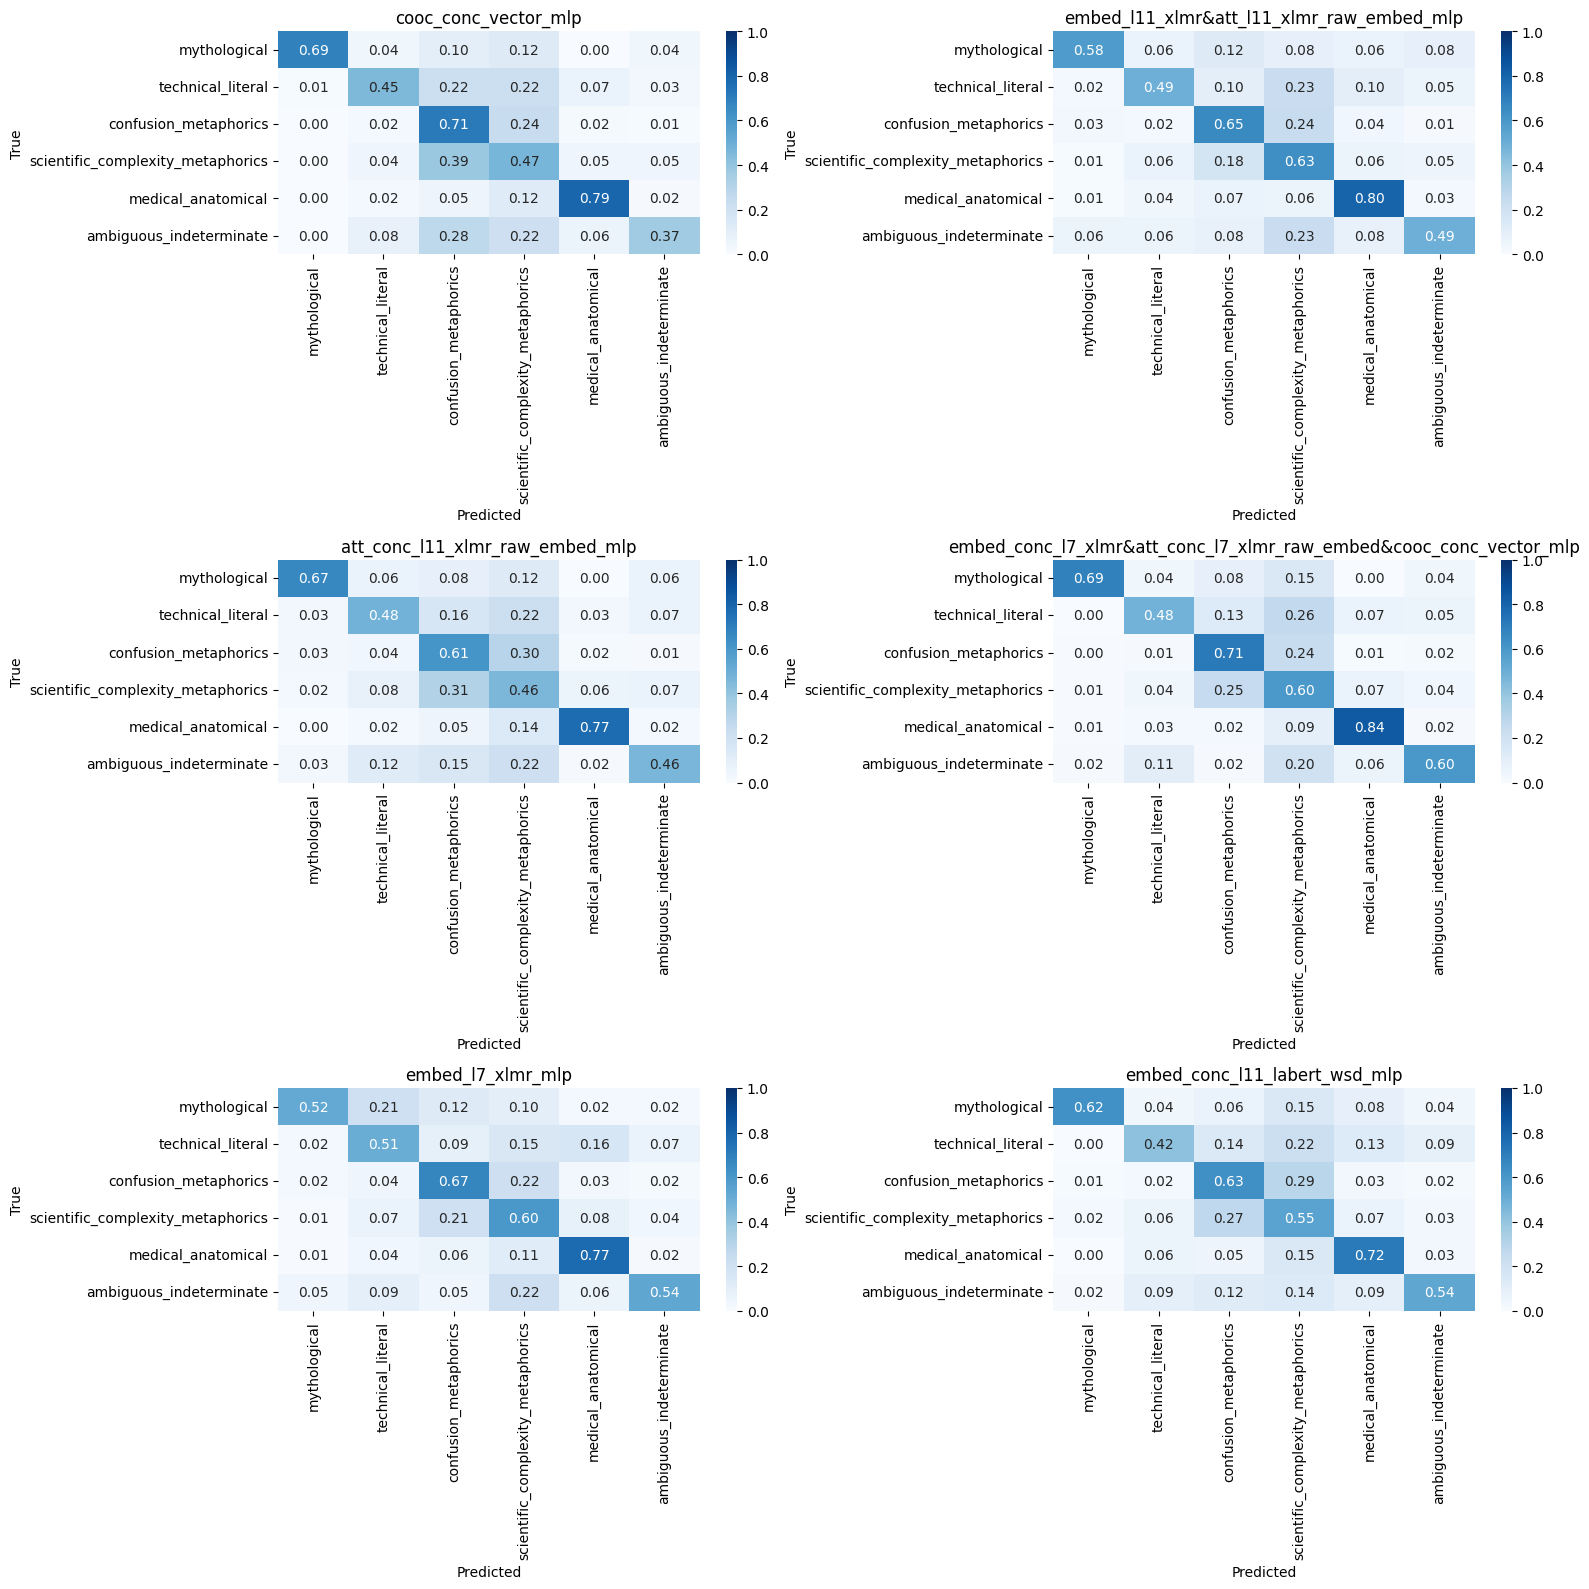

In [132]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.utils.multiclass import unique_labels

titles_ordered = [
    'cooc_vector_mlp',
    'embed_l11_xlmr&att_l11_xlmr_raw_embed_mlp',
    'att_l11_labert_raw_embed_mlp',
    'embed_conc_l8_xlmr&att_conc_l8_xlmr_raw_embed&cooc_conc_vector_mlp',
    'embed_l11_xlmr_mlp',
    'embed_l11_labert_mlp'
]

titles_ordered = [
    'cooc_conc_vector_mlp',
    'embed_l11_xlmr&att_l11_xlmr_raw_embed_mlp',
    'att_conc_l11_xlmr_raw_embed_mlp',
    'embed_conc_l7_xlmr&att_conc_l7_xlmr_raw_embed&cooc_conc_vector_mlp',
    'embed_l7_xlmr_mlp',
    'embed_conc_l11_labert_wsd_mlp']

unique_lbls = ["mythological",
               "technical_literal",
               "confusion_metaphorics",
               "scientific_complexity_metaphorics",
               "medical_anatomical",
               "ambiguous_indeterminate"]

def plot_confusion_matrix(ax, y_true, y_pred, title):
    labels = unique_lbls
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize='true')
    sns.heatmap(
        cm, annot=True, fmt=".2f", cmap="Blues",
        xticklabels=labels, yticklabels=labels, ax=ax,
        vmin=0.0, vmax=1.0
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    ax.tick_params(axis='x')

fig, axes = plt.subplots(3, 2, figsize=(16, 16))
axes = axes.flatten()

for idx, title in enumerate(titles_ordered):
    y_pred = y_preds[title]
    plot_confusion_matrix(axes[idx], y, y_pred, title)

plt.tight_layout()
plt.show()

In [133]:
fig.savefig("../figures/labyrinthus_confusion_matrix_best_models.png", dpi=300)

## T-test

In [147]:
results_df.sort_values("best_model_f1_performance", ascending=False, inplace=True)

In [149]:
results_sent_df = results_df[results_df["context"]=="sentence"]
results_conc_df = results_df[results_df["context"]=="concordance"]

In [152]:
def calc_t_mats(df):
    means = df["best_model_f1_performance"].values
    stds = df["best_model_f1_std"].values
    n = 10  # fixed number of runs per model
    k = len(means)
    # matrices to store results
    t_mat = np.zeros((k, k))
    p_mat = np.zeros((k, k))

    for i in range(k):
        for j in range(k):
            t, p = ttest_ind_from_stats(
                mean1=means[i], std1=stds[i], nobs1=n,
                mean2=means[j], std2=stds[j], nobs2=n,
                equal_var=False  # Welch's t-test (no equal variance assumption)
            )
            t_mat[i, j] = t
            p_mat[i, j] = p

    # Convert to labeled DataFrames for readability
    labels = df["variable_name"]
    t_df = pd.DataFrame(t_mat, index=labels, columns=labels)
    p_df = pd.DataFrame(p_mat, index=labels, columns=labels)
    return t_df, p_df


In [153]:
t_df_sent, p_df_sent = calc_t_mats(results_sent_df)
t_df_conc, p_df_conc = calc_t_mats(results_conc_df)

In [155]:
p_df_conc.head(5)

variable_name,embed_conc_l7_xlmr&att_conc_l7_xlmr_svd400_embed&cooc_conc_vector,embed_conc_l7_xlmr&att_conc_l7_xlmr_raw_embed&cooc_conc_vector,embed_conc_l11_xlmr&att_conc_l11_xlmr_svd400_embed&cooc_conc_vector,embed_conc_l11_xlmr&att_conc_l11_xlmr_raw_embed&cooc_conc_vector,embed_conc_l10_xlmr&att_conc_l10_xlmr_svd400_embed&cooc_conc_vector,embed_conc_l10_xlmr&att_conc_l10_xlmr_raw_embed&cooc_conc_vector,embed_conc_l8_xlmr&att_conc_l8_xlmr_svd400_embed&cooc_conc_vector,embed_conc_l9_xlmr&att_conc_l9_xlmr_svd400_embed&cooc_conc_vector,embed_conc_l8_xlmr&att_conc_l8_xlmr_raw_embed&cooc_conc_vector,embed_conc_l11_labert&att_conc_l11_labert_svd400_embed&cooc_conc_vector,...,att_conc_l9_xlmr_svd400_embed,att_conc_l10_labert_wsd_svd400_embed,att_conc_l11_labert_svd400_embed,att_conc_l7_labert_svd400_embed,att_conc_l8_xlmr_svd400_embed,att_conc_l10_labert_svd400_embed,att_conc_l9_labert_wsd_svd400_embed,att_conc_l7_xlmr_svd400_embed,att_conc_l9_labert_svd400_embed,att_conc_l8_labert_svd400_embed
variable_name,,,,,,,,,,,,,,,,,,,,,
embed_conc_l7_xlmr&att_conc_l7_xlmr_svd400_embed&cooc_conc_vector,1.000000,0.268110,0.175588,0.195841,0.044480,0.043286,0.008506,0.001520,0.000937,0.006211,...,1.004640e-16,5.597485e-17,1.621784e-17,1.298940e-17,2.294621e-15,1.308865e-16,9.164831e-13,1.690060e-18,1.311589e-19,3.606746e-19
embed_conc_l7_xlmr&att_conc_l7_xlmr_raw_embed&cooc_conc_vector,0.268110,1.000000,0.756260,0.722925,0.392557,0.387659,0.183878,0.111113,0.091940,0.135193,...,4.176256e-16,1.884984e-16,1.499169e-16,1.297916e-13,6.361988e-16,1.346372e-16,6.823634e-14,3.213593e-17,4.197073e-15,5.418745e-18
embed_conc_l11_xlmr&att_conc_l11_xlmr_svd400_embed&cooc_conc_vector,0.175588,0.756260,1.000000,0.947231,0.617622,0.612009,0.355646,0.260258,0.228657,0.273618,...,2.837276e-15,1.246297e-15,1.316783e-15,1.229260e-12,1.527167e-15,6.118734e-16,4.503571e-14,3.554498e-16,6.187688e-14,6.115685e-17
embed_conc_l11_xlmr&att_conc_l11_xlmr_raw_embed&cooc_conc_vector,0.195841,0.722925,0.947231,1.000000,0.696514,0.691206,0.442321,0.353333,0.320931,0.352283,...,4.818194e-14,2.146523e-14,2.831872e-14,1.325615e-11,9.774618e-15,7.807059e-15,4.207167e-14,9.587978e-15,1.088040e-12,1.815309e-15
embed_conc_l10_xlmr&att_conc_l10_xlmr_svd400_embed&cooc_conc_vector,0.044480,0.392557,0.617622,0.696514,1.000000,0.993674,0.667279,0.540990,0.488339,0.528126,...,6.029166e-16,2.666044e-16,2.001556e-16,1.303020e-13,1.043021e-15,1.987690e-16,1.218530e-13,3.910814e-17,3.886633e-15,6.278318e-18


In [164]:
p_df_conc.index

Index(['embed_conc_l7_xlmr&att_conc_l7_xlmr_svd400_embed&cooc_conc_vector',
       'embed_conc_l7_xlmr&att_conc_l7_xlmr_raw_embed&cooc_conc_vector',
       'embed_conc_l11_xlmr&att_conc_l11_xlmr_svd400_embed&cooc_conc_vector',
       'embed_conc_l11_xlmr&att_conc_l11_xlmr_raw_embed&cooc_conc_vector',
       'embed_conc_l10_xlmr&att_conc_l10_xlmr_svd400_embed&cooc_conc_vector',
       'embed_conc_l10_xlmr&att_conc_l10_xlmr_raw_embed&cooc_conc_vector',
       'embed_conc_l8_xlmr&att_conc_l8_xlmr_svd400_embed&cooc_conc_vector',
       'embed_conc_l9_xlmr&att_conc_l9_xlmr_svd400_embed&cooc_conc_vector',
       'embed_conc_l8_xlmr&att_conc_l8_xlmr_raw_embed&cooc_conc_vector',
       'embed_conc_l11_labert&att_conc_l11_labert_svd400_embed&cooc_conc_vector',
       'embed_conc_l11_labert&att_conc_l11_labert_raw_embed&cooc_conc_vector',
       'embed_conc_l11_labert_wsd&att_conc_l11_labert_wsd_svd400_embed&cooc_conc_vector',
       'embed_conc_l9_xlmr&att_conc_l9_xlmr_raw_embed&cooc_conc_vecto

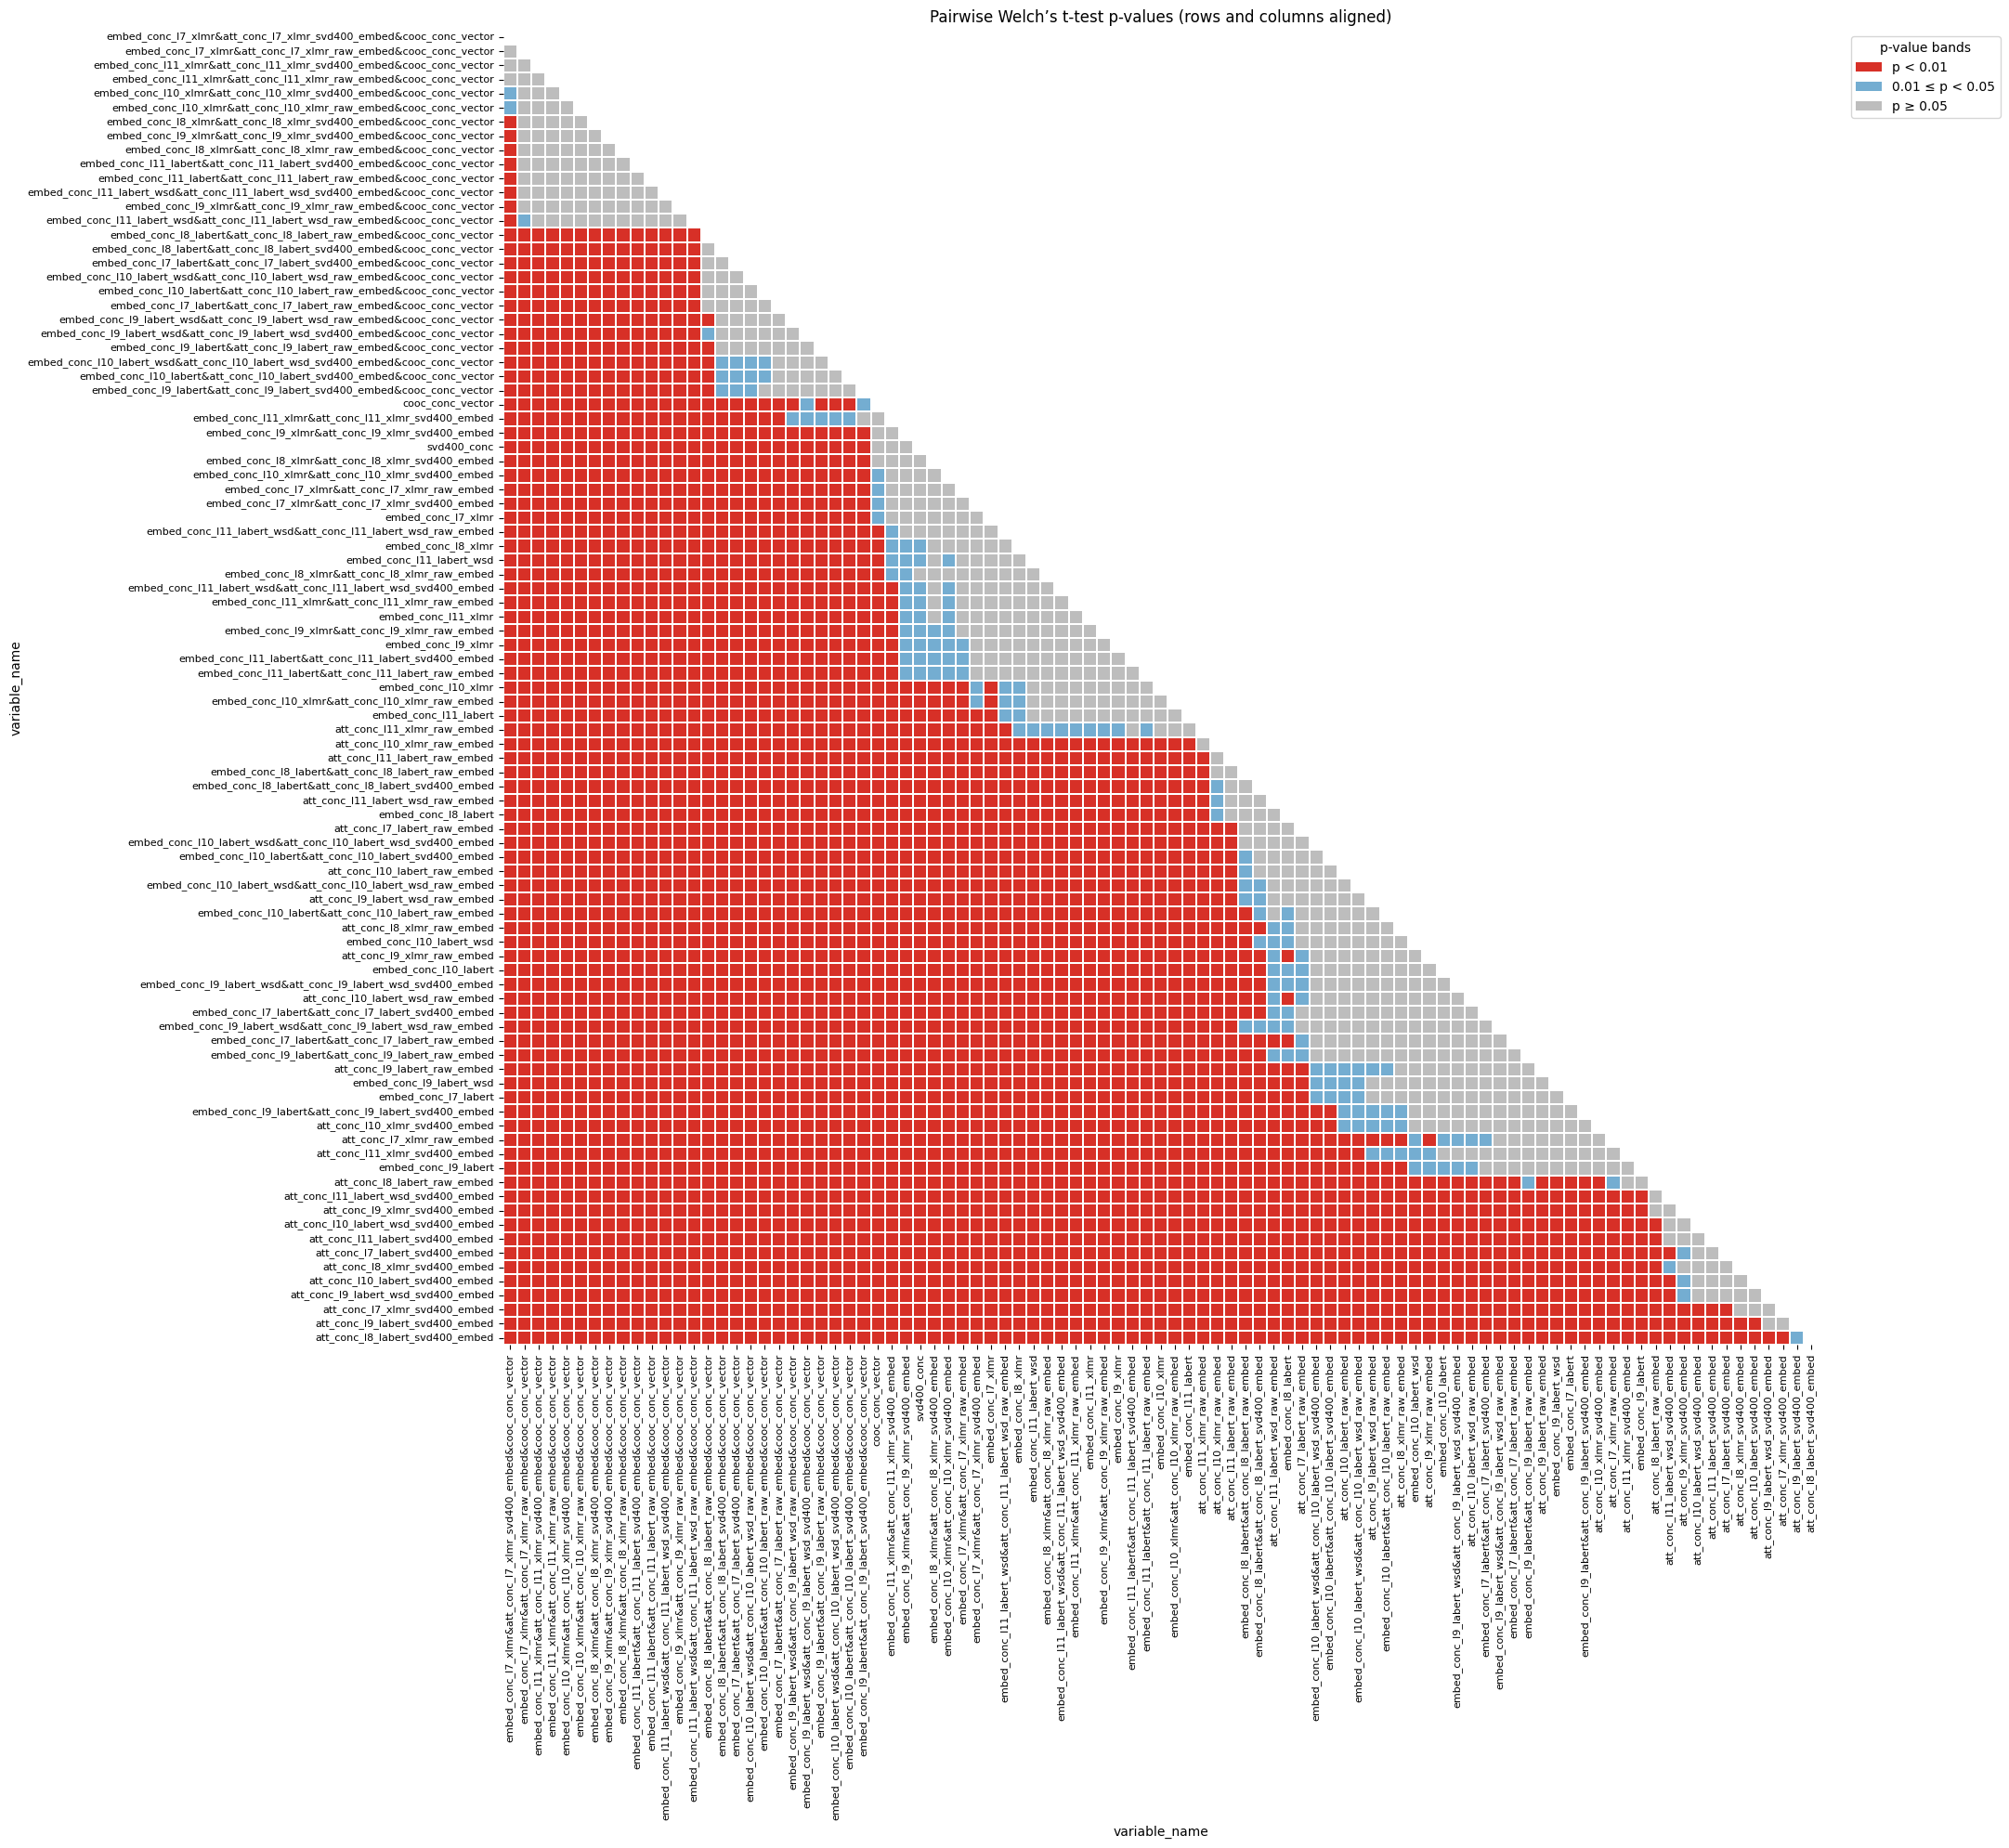

In [174]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

# 1) Align columns to the current row order (use the matrix's own order)
P = p_df_conc.loc[p_df_conc.index, p_df_conc.index]

# 2) Discrete 3-band colors
bounds = [0, 0.01, 0.05, 1.0]
colors = ['#D73027', '#74ADD1', '#BDBDBD']    # red, light blue, grey
cmap = ListedColormap(colors)
norm = BoundaryNorm(bounds, ncolors=len(colors), clip=True)

# 3) Show only the lower triangle (diagonal Top-Left → Bottom-Right)
mask = np.triu(np.ones_like(P, dtype=bool))

fig = plt.figure(figsize=(30, 20))
ax = sns.heatmap(
    P,
    cmap=cmap, norm=norm, mask=mask,
    square=True, linewidths=0.3, linecolor='white',
    cbar=False
)

ax.set_title("Pairwise Welch’s t-test p-values (rows and columns aligned)")
ax.set_xlabel("variable_name"); ax.set_ylabel("variable_name")
ax.tick_params(axis='x', labelrotation=90, labelsize=8)
ax.tick_params(axis='y', labelsize=8)

handles = [
    Patch(facecolor=colors[0], label="p < 0.01"),
    Patch(facecolor=colors[1], label="0.01 ≤ p < 0.05"),
    Patch(facecolor=colors[2], label="p ≥ 0.05"),
]
ax.legend(handles=handles, title="p-value bands",
          bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout(); plt.show()

In [175]:
fig.savefig("../figures/heatmap_p_df_conc.png", dpi=300)

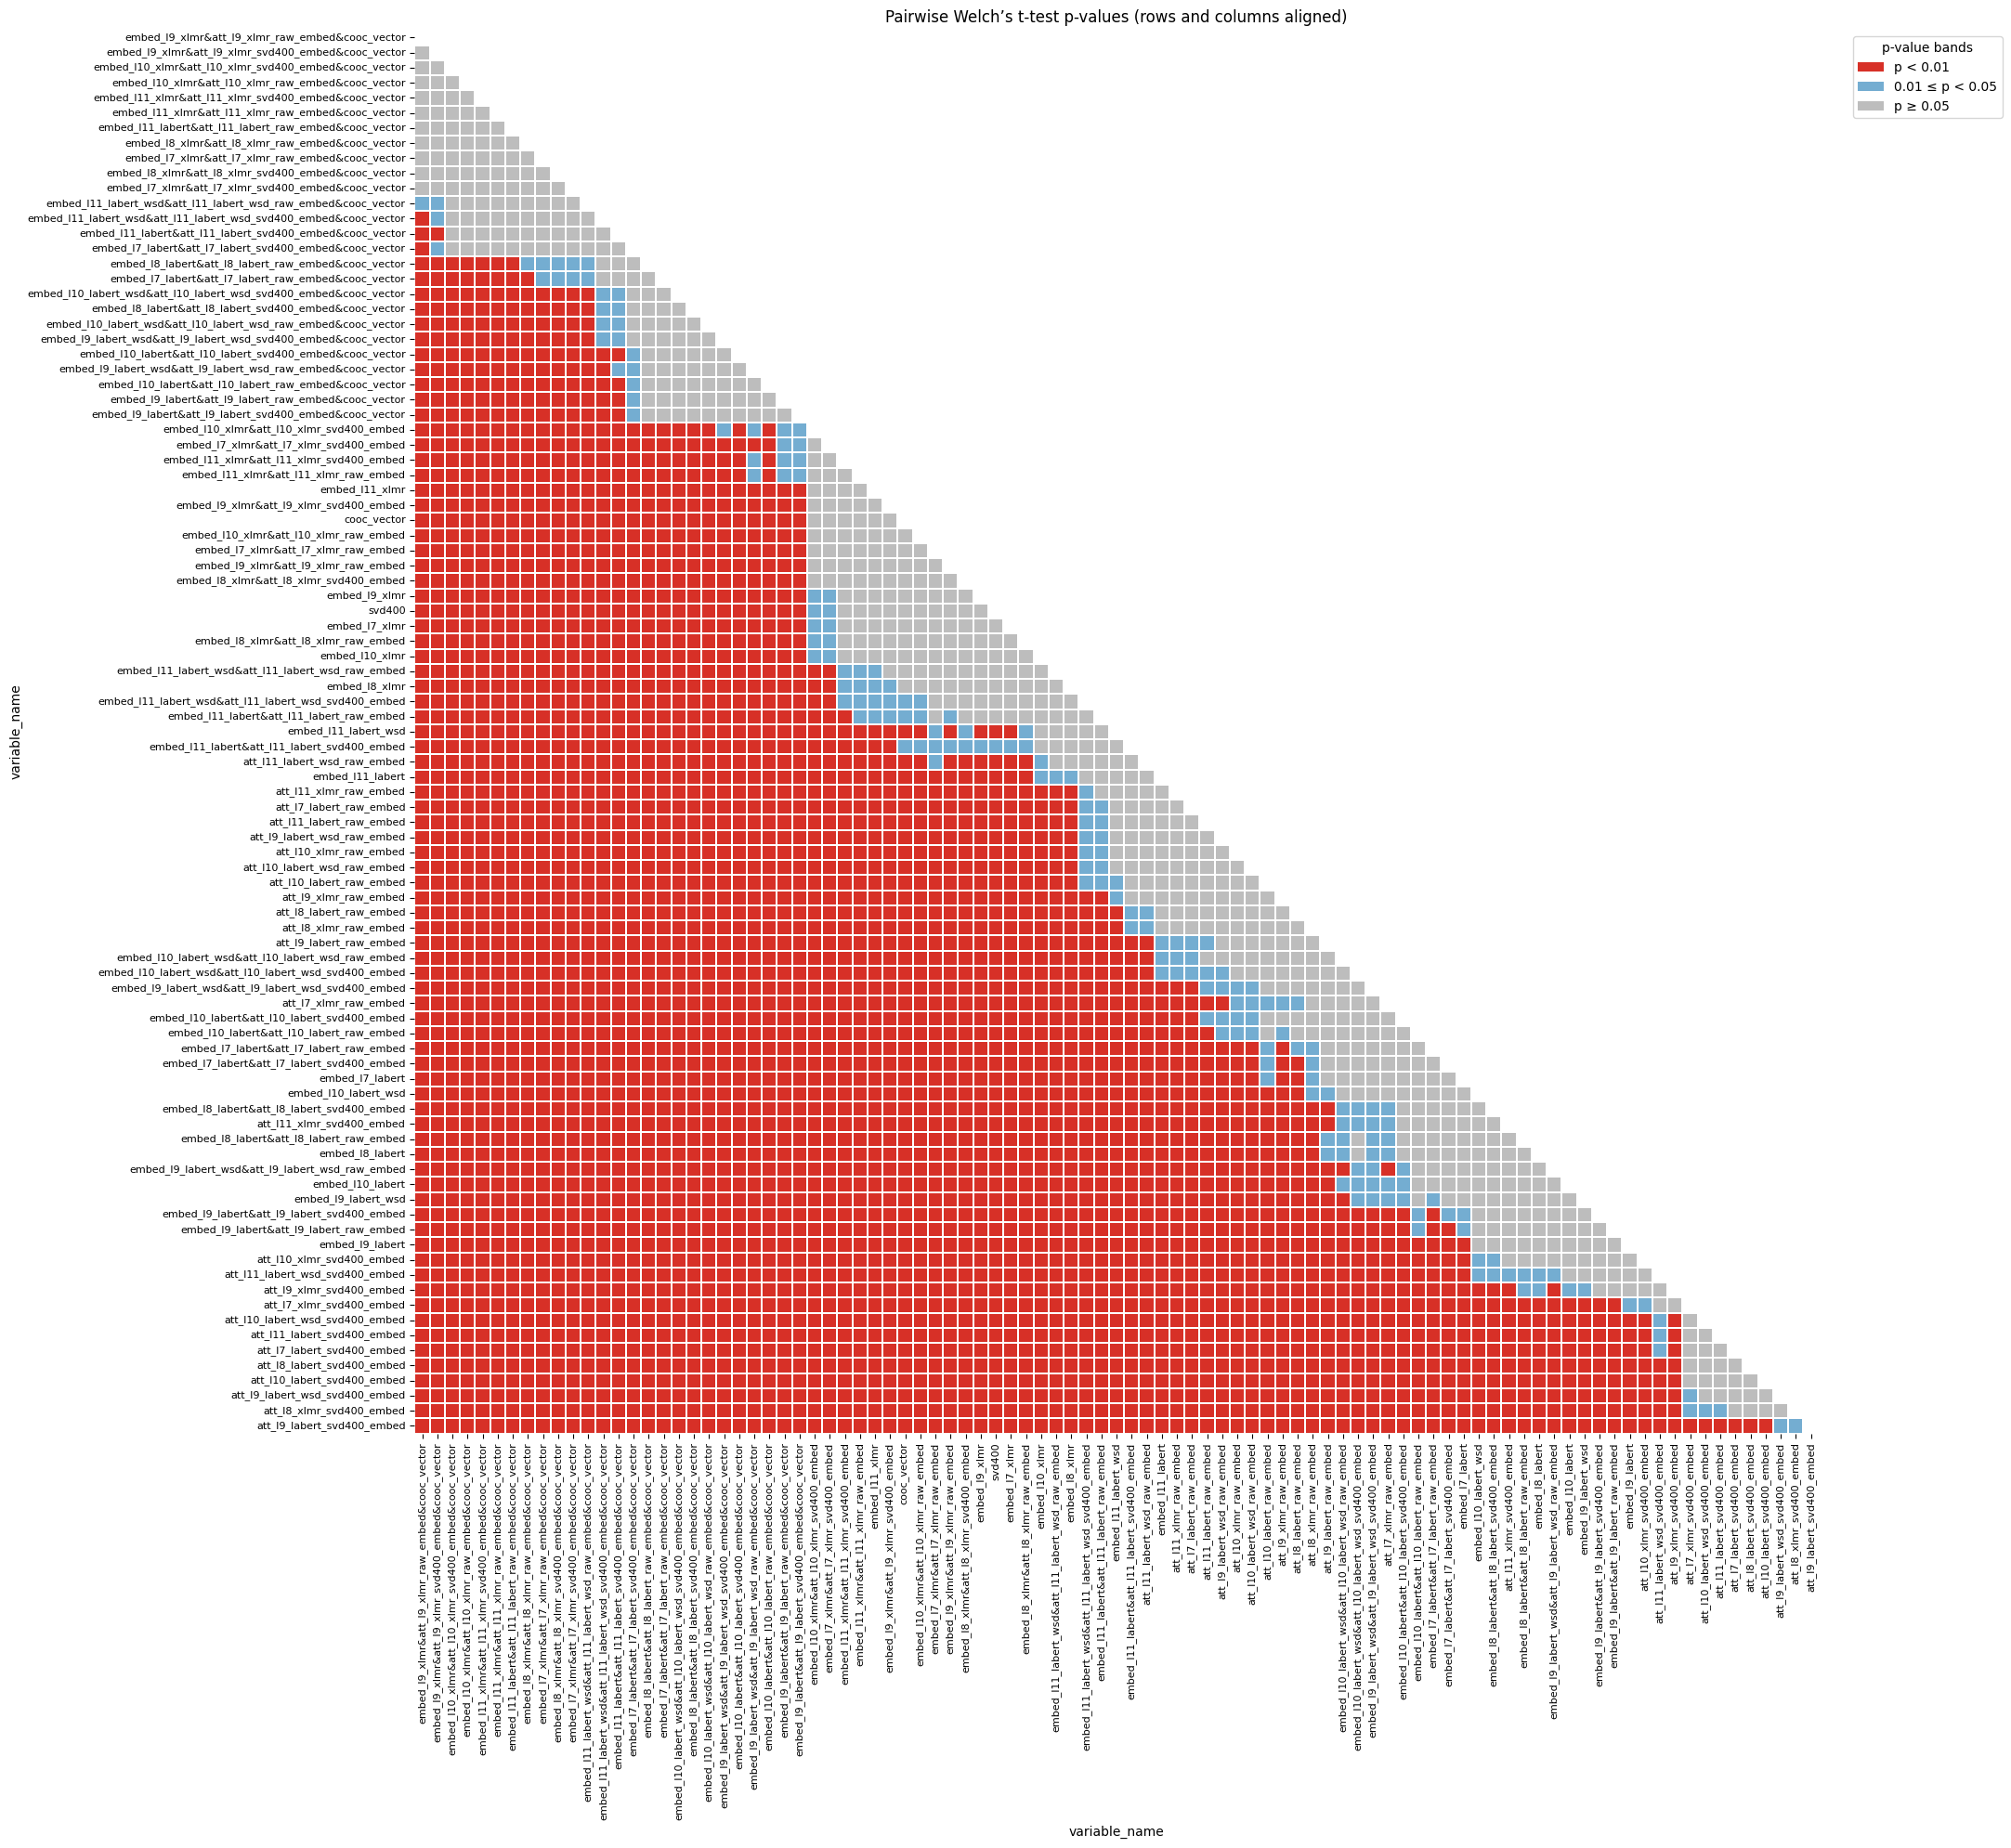

In [180]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

# 1) Align columns to the current row order (use the matrix's own order)
P = p_df_sent.loc[p_df_sent.index, p_df_sent.index]

# 2) Discrete 3-band colors
bounds = [0, 0.01, 0.05, 1.0]
colors = ['#D73027', '#74ADD1', '#BDBDBD']    # red, light blue, grey
cmap = ListedColormap(colors)
norm = BoundaryNorm(bounds, ncolors=len(colors), clip=True)

# 3) Show only the lower triangle (diagonal Top-Left → Bottom-Right)
mask = np.triu(np.ones_like(P, dtype=bool))

fig = plt.figure(figsize=(30, 20))
ax = sns.heatmap(
    P,
    cmap=cmap, norm=norm, mask=mask,
    square=True, linewidths=0.3, linecolor='white',
    cbar=False
)

ax.set_title("Pairwise Welch’s t-test p-values (rows and columns aligned)")
ax.set_xlabel("variable_name"); ax.set_ylabel("variable_name")
ax.tick_params(axis='x', labelrotation=90, labelsize=8)
ax.tick_params(axis='y', labelsize=8)

handles = [
    Patch(facecolor=colors[0], label="p < 0.01"),
    Patch(facecolor=colors[1], label="0.01 ≤ p < 0.05"),
    Patch(facecolor=colors[2], label="p ≥ 0.05"),
]
ax.legend(handles=handles, title="p-value bands",
          bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout(); plt.show()

In [181]:
fig.savefig("../figures/heatmap_p_df_sent.png", dpi=300)

## Backup

In [ ]:
for model in ["xlmr", "labert"]:
    for context in ["sentence", "concordance"]:
        for L in range(7, 12):
            if context == "sentence":
                emb1 = f"embed_l{L}_{model}"
                #emb2 = f"att_l{L}_{model}_svd400_embed"

            else:
                emb1 = f"embed_conc_l{L}_{model}"
                #emb2 = f"att_conc_l{L}_{model}_svd400_embed"


In [119]:
# ------------------------------------------------------------------
# Concatenated features: Contextual + Attention (Layer 11)
# ------------------------------------------------------------------
X = np.stack(labyrinthus_df["svd400"].values)                 # shape (N, 768)

# Concatenate along feature axis → shape (N, 1168)
X_combined = np.concatenate([X], axis=1)

y  = labyrinthus_df["classification_single_label"].values           # 21 classes incl. “other”


# Evaluate
f1_combined = cross_val_score(pipe, X_combined, y, cv=cv, scoring="f1_macro").mean()
print(f"Baseline F1 macro= {f1_combined:.4f}")

Baseline F1 macro= 0.3545


In [19]:
# ------------------------------------------------------------------
# Concatenated features: Contextual + Attention (Layer 11)
# ------------------------------------------------------------------
X_embed = np.stack(labyrinthus_df["embed_conc_l11"].values)                 # shape (N, 768)
X_attn  = np.stack(labyrinthus_df["att_conc_l11_svd400_embed"].values)      # shape (N, 400)

# Concatenate along feature axis → shape (N, 1168)
X_combined = np.concatenate([X_embed, X_attn], axis=1)

# Evaluate
f1_combined = cross_val_score(pipe, X_combined, y, cv=cv, scoring="f1_macro").mean()
print(f"Layer 11 (combined): F1_macro = {f1_combined:.4f}")

Layer 11 (combined): F1_macro = 0.4033


In [25]:


# Initialize CV and target
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y = labyrinthus_df["classification_single"].values

# Define input features
all_features = {
    "sent_ctx": sentence_contextual_embeddings,
    "sent_att": sentence_attention_embeddings,
    "conc_ctx": concordance_contextual_embeddings[::2],  # only embeddings
    "conc_att": concordance_attention_embeddings,
}

# Classifiers
classifiers = {
    "LogisticRegression": LogisticRegression(max_iter=4000, multi_class="multinomial", solver="lbfgs", n_jobs=-1),
    "LinearSVC": LinearSVC(max_iter=4000, dual=False)
}

# Collect results
results = []

for source, cols in all_features.items():
    for col in cols:
        X = np.stack(labyrinthus_df[col].values)
        X_scaled = StandardScaler(with_mean=False).fit_transform(X)
        for clf_name, clf in classifiers.items():
            y_pred = cross_val_predict(clf, X_scaled, y, cv=cv)
            acc = accuracy_score(y, y_pred)
            f1 = f1_score(y, y_pred, average="macro")
            results.append((source, col, clf_name, acc, f1))

# Results summary
results_independent_df = pd.DataFrame(results, columns=["context", "feature", "classifier", "accuracy", "f1_macro"])
results_independent_df

,context,feature,classifier,accuracy,f1_macro
0,sent_ctx,embed_l6,LogisticRegression,0.486900,0.336805
1,sent_ctx,embed_l6,LinearSVC,0.467249,0.331687
2,sent_ctx,embed_l7,LogisticRegression,0.493450,0.347568
3,sent_ctx,embed_l7,LinearSVC,0.484716,0.352115
4,sent_ctx,embed_l8,LogisticRegression,0.482533,0.372390
5,sent_ctx,embed_l8,LinearSVC,0.465066,0.352629
6,sent_ctx,embed_l9,LogisticRegression,0.504367,0.389683
7,sent_ctx,embed_l9,LinearSVC,0.480349,0.374440
8,sent_ctx,embed_l10,LogisticRegression,0.497817,0.347348
9,sent_ctx,embed_l10,LinearSVC,0.486900,0.354883


In [89]:
results_independent_df.to_csv("../data/labyrinthus_classification_results_independent.csv", index=False)

In [28]:
combined_results = []

for L in range(6, 12):
    # sentence context
    X_ctx = np.stack(labyrinthus_df[f"embed_l{L}"].values)
    X_att = np.stack(labyrinthus_df[f"att_l{L}_svd400_embed"].values)
    X = np.concatenate([X_ctx, X_att], axis=1)
    X_scaled = StandardScaler(with_mean=False).fit_transform(X)

    for clf_name, clf in classifiers.items():
        y_pred = cross_val_predict(clf, X_scaled, y, cv=cv)
        acc = accuracy_score(y, y_pred)
        f1 = f1_score(y, y_pred, average="macro")
        combined_results.append((f"sentence_L{L}", clf_name, acc, f1))

    # concordance context
    X_ctx = np.stack(labyrinthus_df[f"embed_conc_l{L}"].values)
    X_att = np.stack(labyrinthus_df[f"att_conc_l{L}_svd400_embed"].values)
    X = np.concatenate([X_ctx, X_att], axis=1)
    X_scaled = StandardScaler(with_mean=False).fit_transform(X)

    for clf_name, clf in classifiers.items():
        y_pred = cross_val_predict(clf, X_scaled, y, cv=cv)
        acc = accuracy_score(y, y_pred)
        f1 = f1_score(y, y_pred, average="macro")
        combined_results.append((f"concordance_L{L}", clf_name, acc, f1))

# Display
combined_df = pd.DataFrame(combined_results, columns=["combo", "classifier", "accuracy", "f1_macro"])

KeyboardInterrupt: 

In [109]:
combined_df

,combo,classifier,accuracy,f1_macro
0,sentence_L6,LogisticRegression,0.538210,0.411450
1,sentence_L6,LinearSVC,0.515284,0.402585
2,concordance_L6,LogisticRegression,0.548035,0.411323
3,concordance_L6,LinearSVC,0.516376,0.411692
4,sentence_L7,LogisticRegression,0.538210,0.411574
5,sentence_L7,LinearSVC,0.527293,0.438656
6,concordance_L7,LogisticRegression,0.550218,0.451794
7,concordance_L7,LinearSVC,0.525109,0.421798
8,sentence_L8,LogisticRegression,0.528384,0.399472
9,sentence_L8,LinearSVC,0.497817,0.393716


In [92]:
combined_df.to_csv("../data/combined_single-layers.csv", index=False)

In [39]:
labyrinthus_df_short = labyrinthus_df[labyrinthus_df["classification_single_label"].isin(["medical_anatomical","mythological", "metaphorical_general","geographical"])]
len(labyrinthus_df_short) / len(labyrinthus_df)

0.7205240174672489

In [85]:
def combined_layers(df, input, layer_range, svd, pipe=None, cv=None, clf=None):
    if pipe is None:
        pipe = make_pipeline(
            StandardScaler(with_mean=False),
            LogisticRegression(max_iter=4000,
                               multi_class="multinomial",
                               solver="lbfgs",
                               n_jobs=-1)
        )
    if cv is None:
        cv = StratifiedKFold(n_splits=5, shuffle=True)
    if clf is None:
        clf = LogisticRegression(max_iter=4000, multi_class="multinomial", solver="lbfgs", n_jobs=-1)

    if input == "sentence":
        X_stack = np.stack([np.stack(df[f"embed_l{L}"].values) for L in layer_range], axis=0)
        X_att_stack = np.stack([np.stack(df[f"att_l{L}_svd400_embed"].values) for L in layer_range], axis=0)
    else:
        X_stack = np.stack([np.stack(df[f"embed_conc_l{L}"].values) for L in layer_range], axis=0)
        X_att_stack = np.stack([np.stack(df[f"att_conc_l{L}_svd400_embed"].values) for L in layer_range], axis=0)

    # Reshape to (n_samples, total_features)
    X_stack = X_stack.transpose(1, 0, 2).reshape(len(df), -1)
    X_att_stack = X_att_stack.transpose(1, 0, 2).reshape(len(df), -1)

    # Concatenate embeddings and attentions
    X = np.concatenate([X_stack, X_att_stack], axis=1)

    # Normalize and reduce
    X_scaled = StandardScaler(with_mean=False).fit_transform(X)
    if svd:
        svd = TruncatedSVD(n_components=800, random_state=42)
        X_scaled = svd.fit_transform(X_scaled)
    y = df["classification_single_label"].values
    y_preds, f1s, accs = [], [], []
    for _ in range(10):
        y_pred = cross_val_predict(clf, X_scaled, y, cv=cv)
        acc = accuracy_score(y, y_pred)
        f1 = f1_score(y, y_pred, average="macro")
        y_preds.append(y_pred)
        f1s.append(f1)
        accs.append(acc)
    return y_preds, f1s, accs

In [86]:
y_preds, f1s, accs = combined_layers(labyrinthus_df, "sentence", layer_range=range(7, 9), svd=True)
f1s

[0.4032171790180076,
 0.38507047031329417,
 0.3837455152385959,
 0.4314610866199769,
 0.38119408962115925,
 0.4340041667353793,
 0.45961275483336916,
 0.41663889575825036,
 0.414103964395645,
 0.44278344806773007]

In [120]:
results_dicts = []

for layer_range in [
    (6,6), (7,7), (8,8), (9,9), (10,10), (11,11),
    (6,7),(7, 8), (8, 9), (9, 10), (10, 11),
    (6,8),(7, 9), (8, 10), (9, 11),
    (6,9),(7, 10), (8, 11),
    (6,10),(7, 11),
    (6,11)
    ]:
    #for svd in [True, False]:
    y_preds, f1s, accs = combined_layers(labyrinthus_df, "sentence", layer_range=layer_range, svd=False)
    results_dicts.append({"Context": "sentence", "Layer range": layer_range, "y_preds" : y_preds, "Accuracies": np.mean(accs), "F1-macros": f1s, "F1_avr" : np.mean(f1s)})
    y_preds, f1s, accs = combined_layers(labyrinthus_df, "concordance", layer_range=layer_range, svd=False)
    results_dicts.append({"Context": "concordance", "Layer range": layer_range, "y_preds" : y_preds, "Accuracies": np.mean(accs), "F1-macros": f1s, "F1_avr" : np.mean(f1s)})

In [121]:
results_df = pd.DataFrame(results_dicts)
results_df

,Context,Layer range,y_preds,Accuracies,F1-macros,F1_avr
0,sentence,"(6, 6)","[[metaphorical_general, metaphorical_general, ...",0.534170,"[0.4287132960239554, 0.4197612538855159, 0.401...",0.402345
1,concordance,"(6, 6)","[[metaphorical_general, metaphorical_general, ...",0.532205,"[0.3923699064467322, 0.41858985959768064, 0.39...",0.400745
2,sentence,"(7, 7)","[[metaphorical_general, metaphorical_general, ...",0.539520,"[0.4313686024542906, 0.43665942696333754, 0.42...",0.429619
3,concordance,"(7, 7)","[[metaphorical_general, metaphorical_general, ...",0.519541,"[0.4078754258548839, 0.40811962700432575, 0.36...",0.399701
4,sentence,"(8, 8)","[[metaphorical_general, metaphorical_general, ...",0.521725,"[0.430975897789401, 0.43033965408836183, 0.431...",0.407748
5,concordance,"(8, 8)","[[metaphorical_general, spiritual_religious, m...",0.527948,"[0.4384224041372657, 0.40879735774140835, 0.42...",0.412273
6,sentence,"(9, 9)","[[metaphorical_general, mythological, metaphor...",0.525218,"[0.41040343080937997, 0.39844929970017245, 0.4...",0.414974
7,concordance,"(9, 9)","[[metaphorical_general, mythological, metaphor...",0.531550,"[0.451828513989122, 0.4329452866125177, 0.4337...",0.425644
8,sentence,"(10, 10)","[[metaphorical_general, mythological, spiritua...",0.548253,"[0.43058108176421095, 0.41343134018155603, 0.4...",0.426820
9,concordance,"(10, 10)","[[metaphorical_general, mythological, metaphor...",0.541703,"[0.39850341200157713, 0.44723034426319225, 0.4...",0.414783


In [122]:
results_df["best_perf_i"] =  results_df["F1-macros"].apply(lambda my_list: max(enumerate(my_list), key=lambda x: x[1])[0])

In [123]:
results_df["best_perf"] =  results_df["F1-macros"].apply(lambda my_list: max(enumerate(my_list), key=lambda x: x[1])[1])

In [124]:
results_df

,Context,Layer range,y_preds,Accuracies,F1-macros,F1_avr,best_perf_i,best_perf
0,sentence,"(6, 6)","[[metaphorical_general, metaphorical_general, ...",0.534170,"[0.4287132960239554, 0.4197612538855159, 0.401...",0.402345,0,0.428713
1,concordance,"(6, 6)","[[metaphorical_general, metaphorical_general, ...",0.532205,"[0.3923699064467322, 0.41858985959768064, 0.39...",0.400745,3,0.419482
2,sentence,"(7, 7)","[[metaphorical_general, metaphorical_general, ...",0.539520,"[0.4313686024542906, 0.43665942696333754, 0.42...",0.429619,8,0.456649
3,concordance,"(7, 7)","[[metaphorical_general, metaphorical_general, ...",0.519541,"[0.4078754258548839, 0.40811962700432575, 0.36...",0.399701,3,0.431403
4,sentence,"(8, 8)","[[metaphorical_general, metaphorical_general, ...",0.521725,"[0.430975897789401, 0.43033965408836183, 0.431...",0.407748,2,0.431843
5,concordance,"(8, 8)","[[metaphorical_general, spiritual_religious, m...",0.527948,"[0.4384224041372657, 0.40879735774140835, 0.42...",0.412273,4,0.448307
6,sentence,"(9, 9)","[[metaphorical_general, mythological, metaphor...",0.525218,"[0.41040343080937997, 0.39844929970017245, 0.4...",0.414974,2,0.442328
7,concordance,"(9, 9)","[[metaphorical_general, mythological, metaphor...",0.531550,"[0.451828513989122, 0.4329452866125177, 0.4337...",0.425644,0,0.451829
8,sentence,"(10, 10)","[[metaphorical_general, mythological, spiritua...",0.548253,"[0.43058108176421095, 0.41343134018155603, 0.4...",0.426820,6,0.437002
9,concordance,"(10, 10)","[[metaphorical_general, mythological, metaphor...",0.541703,"[0.39850341200157713, 0.44723034426319225, 0.4...",0.414783,7,0.448885


In [125]:
results_df.to_csv("../data/classification_combining-layers.csv", index=False)

In [101]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.utils.multiclass import unique_labels

def plot_confusion_matrix(y_true, y_pred):
    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=unique_labels(y_true, y_pred))
    labels = unique_labels(y_true, y_pred)

    # Create figure and axis
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels, ax=ax)

    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    ax.set_title("Confusion Matrix")
    plt.xticks(rotation=45)
    plt.tight_layout()

    return fig


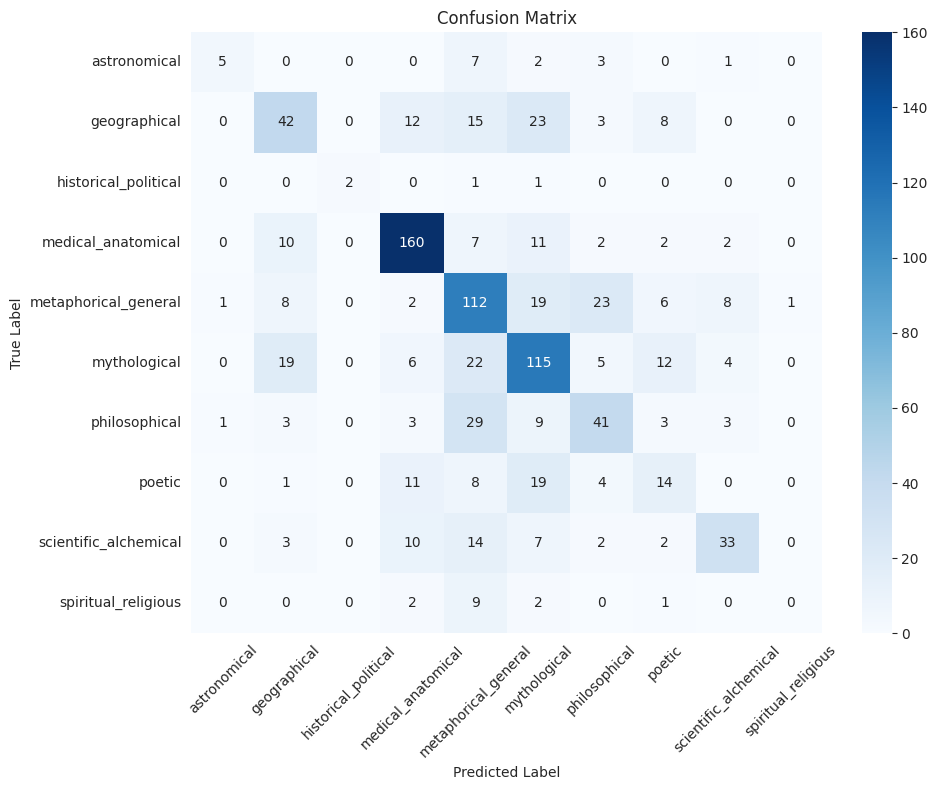

In [102]:
y_pred = results_df.iloc[21]["y_preds"][5]
fig = plot_confusion_matrix(labyrinthus_df["classification_single_label"], y_pred)
# fig.savefig("confusion_matrix.png")

In [103]:
fig.savefig("../figures/labyrinthus_classification_confusion_matrix_l8-12.png", dpi=300)

In [ ]:
fig.savefig("../figures/labyrinthus_classification_confusion_matrix_l8-12.png", dpi=300)

In [85]:
labyrinthus_df.head(5)

,author,title,grela_id,sentence_id,sentence_text,context_3sents,tokens,concordance_tokens,classification,not_before,...,embed_l8,att_l8,embed_l9,att_l9,embed_l10,att_l10,embed_l11,att_l11,svd300,svd400
0,Humbertus Silvae Candidae1010-1061,Adversus Simoniacos,cc_10012,cc_10012_2812,"Exploret qui potest qualiter, et qua hunc laby...","Si enim, ut philosophus allegat, qui non prohi...","[{'char_end': 8, 'char_start': 0, 'lemma': 'ex...","[{'char_end': 303, 'char_start': 299, 'lemma':...",metaphorical,1010.0,...,"[-0.5996939, -0.08402276, 0.24582314, 0.246073...","{'exploro': {'weight': 0.007501654326915741, '...","[-0.4901215, -0.014518358, 0.11257135, -0.0287...","{'exploro': {'weight': 0.0040437448769807816, ...","[-0.22389103, -0.08037936, 0.4684307, -0.07405...","{'exploro': {'weight': 0.0023853108286857605, ...","[0.015361398, -0.05652492, 0.28677505, -0.2481...","{'exploro': {'weight': 0.004686874337494373, '...","[1.0248758, -0.109425925, 0.18502058, -0.12902...","[1.0248758, -0.10942612, 0.18502046, -0.129020..."
1,Petrus Damianus,"Patrologia Latina, vol. 145",cc_10077,cc_10077_50,"Et poenae factus est auctor, qui poenalis laby...","Protinus igitur projectus in taurum, quod infe...","[{'char_end': 2, 'char_start': 0, 'lemma': 'et...","[{'char_end': 83, 'char_start': 75, 'lemma': '...","poetic, metaphorical",1007.0,...,"[-0.55678105, -0.031190008, 0.18337364, 0.4370...","{'et': {'weight': 0.003848183201625943, 'piece...","[-0.4923613, -0.1829148, 0.15112661, 0.3343788...","{'et': {'weight': 0.006557437125593424, 'piece...","[-0.3993842, -0.17896965, 0.33668458, 0.163039...","{'et': {'weight': 0.0010180403478443623, 'piec...","[-0.053815715, -0.15342486, 0.2319887, -0.1168...","{'et': {'weight': 0.005556851625442505, 'piece...","[0.96935123, -0.052010406, 0.13268225, -0.0820...","[0.9693511, -0.052010484, 0.1326823, -0.082074..."
2,Rodulphus S. Trudonis,Vita S. Lietberti,cc_10161,cc_10161_32,mirantibus magistris penetrat labyrinthos Scri...,Ducitur sitibundo pectore currens ad fontem ph...,"[{'char_end': 10, 'char_start': 0, 'lemma': 'm...","[{'char_end': 144, 'char_start': 136, 'lemma':...","metaphorical, philosophical",NaN,...,"[-0.070512734, -0.010591162, -0.093808964, 0.2...","{'miro': {'weight': 0.03680548816919327, 'piec...","[-0.10879725, 0.09882534, -0.008079263, 0.1313...","{'miro': {'weight': 0.01636236347258091, 'piec...","[-0.23412725, 0.0044030286, 0.25399756, 0.1273...","{'miro': {'weight': 0.00277316989377141, 'piec...","[-0.034478694, 0.042206235, 0.24609125, -0.210...","{'miro': {'weight': 0.004833581391721964, 'pie...","[0.98060316, -0.115663484, -0.026802924, -0.18...","[0.98060316, -0.11566342, -0.02680232, -0.1812..."
3,Domnizo Canusinus,Vita et carmina Mathildis,cc_10261,cc_10261_892,"Ista fuit, quae par habuit regemque Deumque, H...","Ista fuit, quae diripuit Paulumque Petrumque; ...","[{'char_end': 4, 'char_start': 0, 'lemma': 'is...","[{'char_end': 43, 'char_start': 40, 'lemma': '...","metaphorical, poetic",1130.0,...,"[-0.20573536, 0.0940672, 0.14274016, 0.2886553...","{'iste': {'weight': 0.001744522713124752, 'pie...","[-0.23654726, 0.043308813, 0.059855238, 0.2533...","{'iste': {'weight': 0.0017882290994748473, 'pi...","[-0.23956929, -0.014918415, 0.138808, 0.211936...","{'iste': {'weight': 0.0018670707941055298, 'pi...","[0.022103995, -0.04788581, 0.04260912, -0.0920...","{'iste': {'weight': 0.005081632640212774, 'pie...","[1.101139, 0.7583047, -0.082435116, -0.2232320...","[1.1011388, 0.75830466, -0.08243356, -0.223232..."
4,Durandus Trobarnensis,Liber de corpore et sanguine Christi,cc_10298,cc_10298_920,Uerum quia quidam peruersi ex hac tanti doctor...,Xxui. | Uerum quia quidam peruersi ex hac tant...,"[{'char_end': 5, 'char_start': 0, 'lemma': 'ue...","[{'char_end': 10, 'char_start': 6, 'lemma': 'q...",metaphorical,NaN,...,"[-0.41097933, 0.07569985, 0.18987988, 0.161353...","{'uerus': {'weight': 0.005245175678282976, 'pi...","[-0.40861088, -0.1697307, 0.14324735, 0.064479...","{'uerus': {'wei

In [ ]:
surface = labyrinthus_df'["concordance_tokens"].apply(
    lambda toks: next(t for t in toks if t["lemma"].lower() == "labyrinthus")["token_text"].lower()
)

palette = {f: c for f, c in zip(surface.unique(), plt.cm.Set1.colors)}


fig, [ax1, ax2] = plt.subplots(2,1, figsize=(5, 5))

emb_array = np.stack(labyrinthus_df["embed_hybrid_allpos"].values)
proj_series = compute_projections(emb_array)

proj_key = "umap_10_0.05"
xs = proj_series.str[proj_key].str["x"]
ys = proj_series.str[proj_key].str["y"]

ax1.scatter(xs, ys, c=surface.map(palette), s=8)
ax1.set_title(f"{proj_key} of lemmatized target word embeddings coloured by surface form")
ax1.axis("off")

emb_array = np.stack(labyrinthus_df["embed_surface_allpos"].values)
proj_series = compute_projections(emb_array)

proj_key = "umap_10_0.05"

xs = proj_series.str[proj_key].str["x"]
ys = proj_series.str[proj_key].str["y"]
ax2.scatter(xs, ys, c=surface.map(palette), s=8)
ax2.set_title(f"{proj_key} of un-lemmatized target word embeddings coloured by surface form")
ax2.axis("off")

plt.show()